In [170]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader,Subset, RandomSampler
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [44]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [45]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [346]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), p_dropout=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        if use_sigmoid:           # keep preds in [0,1] since y is normalized
            layers += [nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        # (N, 1)

def mse_loss(pred, target,weight= None, eps=1e-12):
    # return torch.sqrt(nn.functional.mse_loss(pred, target) + eps)
    return nn.functional.mse_loss(pred, target)+ eps

# def mse_loss(pred, target, weight=None, eps=1e-12):
#     se = (pred.view(-1) - target.view(-1))**2
#     if weight is None:
#         return se.mean()
#     w = weight.view(-1).clamp_min(0)
#     return (w * se).sum() / (w.sum() + eps)

def train_regressor(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_mse, n_batches = 0.0, 0
        for batch in train_loader:
            xb, yb = batch
            wb = None
            
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            # print(preds[:5],yb[:5])
            loss = mse_loss(preds, yb, weight= None)
            loss.backward()
            opt.step()

            tot_mse += loss.item()
            # print(tot_mse)
            n_batches += 1
            # print(n_batches)
        # print(f"Epoch {ep:02d} | train MSE {tot_mse / max(1, n_batches):.6f}")
            
        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    xb, yb, wb = batch
                    wb = wb.to(device).float().view(-1, 1)
                else:
                    xb, yb = batch
                    wb = None
                preds = model(xb)
                val_rmse += mse_loss(preds, yb, wb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_mse = tot_mse / max(1, n_batches)
        # print(tot_mse)
        if ep % 100 == 0:
            print(f"Epoch {ep:02d} | train MSE {tr_mse:.6f} | val MSE {val_rmse:.6f}")
        
        if tot_mse <= best_tr:
            if val_rmse <= best_val:
                best_tr = tot_mse
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                print(f"Best Mode: Epoch {ep:02d} | train MSE {tr_mse:.6f} | val MSE {best_val:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def train_regressor_stratify(model, train_loader_0,train_loader_1, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_mse, n_batches = 0.0, 0
        for batch0,batch1 in zip(train_loader_0,train_loader_1):
            # if len(batch0) == 3:
            #     xb, yb, wb = batch
            #     wb = wb.to(device).float().view(-1, 1)
            # else:
            # print(len(batch0))
            xb_0, yb_0 = batch0
            xb_1, yb_1 = batch1
            xb = torch.cat([xb_0, xb_1], dim=0)
            yb = torch.cat([yb_0, yb_1], dim=0)
            # print(xb.shape,yb.shape)
            wb = None
            
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            # print(preds[:5],yb[:5])
            loss = mse_loss(preds, yb, weight= None)
            loss.backward()
            opt.step()

            tot_mse += loss.item()
            # print(tot_mse)
            n_batches += 1
            # print(n_batches)
        # print(f"Epoch {ep:02d} | train MSE {tot_mse / max(1, n_batches):.6f}")
            
        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    xb, yb, wb = batch
                    wb = wb.to(device).float().view(-1, 1)
                else:
                    xb, yb = batch
                    wb = None
                preds = model(xb)
                val_rmse += mse_loss(preds, yb, wb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_mse = tot_mse / max(1, n_batches)
        # print(tot_mse)
        if ep % 100 == 0:
            print(f"Epoch {ep:02d} | train MSE {tr_mse:.6f} | val MSE {val_rmse:.6f}")
        
        if tot_mse <= best_tr:
            # if val_rmse <= best_val:
            best_tr = tot_mse
            best_val = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"Best Mode: Epoch {ep:02d} | train MSE {tr_mse:.6f} | val MSE {val_rmse:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        if isinstance(X, torch.Tensor):
            X_t = X.to(device).float()
        else:
            X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
        preds = model(X_t).cpu().squeeze(1)
    return preds

In [405]:
def train_model(
    X, Y, weight=None,
    model=None, 
    ratio_val=0.1,
    hidden=(512, 256),
    p_dropout=0.1,
    epochs=500,
    lr=1e-4,
    weight_decay=1e-4,
    batch_size_train=32,
    batch_size_val=None,     # None, using full val set
    use_sigmoid=False,
    seed = None
):
    n = X.shape[0]

    if weight is None:
        weight = np.ones(n, dtype=np.float32)
    elif np.isscalar(weight):
        weight = np.full(n, float(weight), dtype=np.float32)
    else:
        weight = np.asarray(weight, dtype=np.float32)

    
    # len_val = 1 # Ignoring Validating set
    len_val = max(1, int(n * ratio_val))
    idx_val = np.arange(n-len_val,n)
    idx_tr  = np.setdiff1d(np.arange(n), idx_val)
    # rng = np.random.default_rng(seed) if seed is not None else None
    # idx_val = (rng.choice(n, size=len_val, replace=False) 
    #            if rng is not None else np.random.choice(n, len_val, replace=False))
    # idx_tr  = np.setdiff1d(np.arange(n), idx_val)
    # idx_val = np.arange(n-len_val,n)
    # idx_tr  = np.setdiff1d(np.arange(n), idx_val)

    X_val, Y_val, w_val = X[idx_val], Y[idx_val], weight[idx_val]
    X_tr,  Y_tr, w_tr  = X[idx_tr],  Y[idx_tr], weight[idx_tr]

    train_ds = TensorDataset(
        torch.from_numpy(X_tr.astype(np.float32)),
        torch.from_numpy(Y_tr.astype(np.float32)),
        # torch.from_numpy(w_tr.astype(np.float32))
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val.astype(np.float32)),
        torch.from_numpy(Y_val.astype(np.float32)),
        # torch.from_numpy(w_val.astype(np.float32))
    )

    if batch_size_val is None:
        batch_size_val = len(val_ds)  # evaluate on all val at once

    train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size_val,   shuffle=False, drop_last=False)
    print(hidden,hidden,hidden,epochs,lr,weight_decay)
    if model is None:
        print('initialize',X.shape[1])
        model = MLPRegressor(
            input_dim=X.shape[1],
            hidden=hidden,
            use_sigmoid=False,
            p_dropout = p_dropout
        )

    model = train_regressor(
        model, train_loader, val_loader,
        epochs=epochs, lr=lr, weight_decay=weight_decay
    )
    return model

def predict_paths(model, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        if df_paths.shape[1] == 1:
            cand_pe = position_encoder(df_paths, type="onehot")
        else:
            cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = predict(model,features)
    return preds

def choose_next_state(model_action, model_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime_action)
    df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)
    preds_action = predict_paths(model_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(model_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, rewards_matrix

def run_inference(model_action, model_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(model_action, model_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma,normalization=True)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    return pregret,preds

# Offline - Batch mode

In [416]:
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts = [128]
# Ts = [1024,1250,1500]
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 6
batch_size_train = 32
epochs = 2000
normalizer = 1
PREGRETS = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=3000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    np.random.shuffle(irewards)
    PREGRET = []
    for T in Ts:
        # initial dataset
        T_val = int(0.1*T)
        T_initial = T - T_val
        X_T = new_state_oh[:T,:]
        X_train = new_state_oh[:T_initial,:]
        Y_train_action = irewards[:T_initial]
        

        X_val = new_state_oh[T_initial:T,:]
        Y_val_action = np.array(irewards[T_initial:T]).reshape(-1,1)
        print(X_train.shape,Y_train_action.shape,X_val.shape,Y_val_action.shape)
        if T >= 1024:
            batch_size_train = 64
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), 
                                 torch.from_numpy(Y_train_action.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), 
                                 torch.from_numpy(Y_val_action.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)
        mlp_action = MLPRegressor(input_dim=X_train.shape[1], hidden=(128,12), p_dropout=0.1, use_sigmoid=False)
        mlp_action = train_regressor(mlp_action, train_loader, val_loader, epochs=1500, lr=1e-2,weight_decay = 1e-4)

       
        # Y_train_value = make_weighted_target(Y_train_action, 0.9,T = T_initial,normalization = True)
        # Y_val_value = make_weighted_target(Y_val_action, 0.9,T = T_val,normalization = True)
        prewards = make_weighted_target(irewards[:T], gamma,T = T,normalization = False)
        prewards = prewards/normalizer
        is_pos = (prewards > threshold).astype(int)
        targets = is_pos
        train_idx, valid_idx= train_test_split(
        np.arange(len(targets)),
        test_size=0.1,
        shuffle=True,
        stratify=targets)

        X_train_value = X_T[train_idx,:]
        X_val_value = X_T[valid_idx,:]
        Y_train_value = prewards[train_idx]
        Y_val_value =  prewards[valid_idx]

        train_ds = TensorDataset(torch.from_numpy(X_train_value.astype(np.float32)), 
                                 torch.from_numpy(Y_train_value.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val_value.astype(np.float32)), 
                                 torch.from_numpy(Y_val_value.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)
        mlp_val = MLPRegressor(input_dim=X_train.shape[1], hidden=(512,256), p_dropout=0.1, use_sigmoid=False)
        mlp_val = train_regressor(mlp_val, train_loader, val_loader, epochs=2000, lr=1e-4,weight_decay = 1e-4)
        

        ## Statify
        # is_pos = (prewards > threshold).astype(int)
        # targets = is_pos
        # train_idx, valid_idx= train_test_split(
        # np.arange(len(targets)),
        # test_size=0.1,
        # shuffle=True,
        # stratify=targets)

        # Y_train_value = make_weighted_target(Y_train_action, 0.9,T = T_initial,normalization = True)
        # Y_val_value = make_weighted_target(Y_val_action, 0.9,T = T_val,normalization = True)
        # ds_value = TensorDataset(torch.from_numpy(X_T.astype(np.float32)), torch.from_numpy(prewards.astype(np.float32)))
        # ds_tr, ds_va = Subset(ds_value, train_idx), Subset(ds_value, valid_idx)
        # y_tr = targets[train_idx]
        # idx0_tr  = np.where(y_tr == 0)[0].tolist()         # indices relative to ds_tr
        # idxn0_tr = np.where(y_tr != 0)[0].tolist()
        # print(len(idx0_tr),len(idxn0_tr))
        # train_loader_0  = DataLoader(
        #     Subset(ds_tr, idx0_tr),batch_size=int(batch_size_train/2),
        #     sampler=RandomSampler(idx0_tr, replacement=True),drop_last=True,)
        # train_loader_n0 = DataLoader(
        #     Subset(ds_tr, idxn0_tr),batch_size=int(batch_size_train/2),
        #     sampler=RandomSampler(idxn0_tr, replacement=True),drop_last=True,)
        # val_loader = DataLoader(ds_va, batch_size=len(valid_idx), shuffle=False)
        # print(len(ds_tr),len(train_loader_0.dataset),len(train_loader_n0.dataset),len(val_loader.dataset)) 
        # mlp_val = MLPRegressor(input_dim=X_train.shape[1], hidden=(256,128), p_dropout=0, use_sigmoid=True)
        # mlp_val = train_regressor_stratify(mlp_val, train_loader_0, train_loader_n0, val_loader, epochs=5000, lr=1e-2,weight_decay = 1e-4)
        
        current_state = states[T,0]
        start_state = current_state
        pregret_val,pred = run_inference(mlp_action, mlp_val, start_state, T, t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)
    PREGRETS.append(PREGRET)

(116, 57) (116,) (12, 57) (12, 1)
Best Mode: Epoch 01 | train MSE 0.326518 | val MSE 15.804345
Best Mode: Epoch 04 | train MSE 0.215661 | val MSE 15.697219
Best Mode: Epoch 07 | train MSE 0.188727 | val MSE 15.663567
Best Mode: Epoch 08 | train MSE 0.140142 | val MSE 15.591804
Best Mode: Epoch 09 | train MSE 0.128820 | val MSE 15.175256
Best Mode: Epoch 11 | train MSE 0.078541 | val MSE 15.073741
Epoch 100 | train MSE 0.020420 | val MSE 16.258186
Epoch 200 | train MSE 0.043756 | val MSE 15.906960
Epoch 300 | train MSE 0.011439 | val MSE 15.507035
Epoch 400 | train MSE 0.018784 | val MSE 15.731636
Epoch 500 | train MSE 0.041127 | val MSE 16.335756
Epoch 600 | train MSE 0.007807 | val MSE 15.896019
Epoch 700 | train MSE 0.011185 | val MSE 16.292597
Epoch 800 | train MSE 0.014630 | val MSE 16.383623
Epoch 900 | train MSE 0.036953 | val MSE 16.179056
Epoch 1000 | train MSE 0.006883 | val MSE 16.530619
Epoch 1100 | train MSE 0.009666 | val MSE 16.407349
Epoch 1200 | train MSE 0.030486 | val

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/1161624281.py:19: UserWarning: Using a target size (torch.Size([12])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return nn.functional.mse_loss(pred, target)+ eps
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/1161624281.py:19: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return nn.functional.mse_loss(pred, target)+ eps


Best Mode: Epoch 06 | train MSE 15.693931 | val MSE 9.244107
Best Mode: Epoch 08 | train MSE 13.467496 | val MSE 8.819892
Best Mode: Epoch 11 | train MSE 13.088806 | val MSE 8.510030
Best Mode: Epoch 13 | train MSE 11.127406 | val MSE 8.509510
Epoch 100 | train MSE 0.254736 | val MSE 14.122388
Epoch 200 | train MSE 0.110053 | val MSE 14.001037
Epoch 300 | train MSE 0.131473 | val MSE 14.050310
Epoch 400 | train MSE 0.060531 | val MSE 13.954522
Epoch 500 | train MSE 0.065972 | val MSE 13.406747
Epoch 600 | train MSE 0.055907 | val MSE 13.731867
Epoch 700 | train MSE 0.072904 | val MSE 13.815466
Epoch 800 | train MSE 0.047165 | val MSE 13.649337
Epoch 900 | train MSE 0.056240 | val MSE 13.410106
Epoch 1000 | train MSE 0.060833 | val MSE 13.595073
Epoch 1100 | train MSE 0.040860 | val MSE 13.328139
Epoch 1200 | train MSE 0.048919 | val MSE 13.367736
Epoch 1300 | train MSE 0.059024 | val MSE 13.172146
Epoch 1400 | train MSE 0.044698 | val MSE 13.390944
Epoch 1500 | train MSE 0.050802 | val

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/2982025970.py:82: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  preds[:, i] = predict(model,features)


rep 0, T_train 128, pregret=2.2354
(116, 57) (116,) (12, 57) (12, 1)
Best Mode: Epoch 01 | train MSE 4.010138 | val MSE 1.260218
Best Mode: Epoch 02 | train MSE 3.850761 | val MSE 1.245435
Epoch 100 | train MSE 0.141956 | val MSE 2.162076
Epoch 200 | train MSE 0.233398 | val MSE 2.565613
Epoch 300 | train MSE 0.253483 | val MSE 3.056432
Epoch 400 | train MSE 0.674991 | val MSE 3.234436
Epoch 500 | train MSE 0.080241 | val MSE 2.927323
Epoch 600 | train MSE 0.226095 | val MSE 2.989244
Epoch 700 | train MSE 0.245712 | val MSE 1.776104
Epoch 800 | train MSE 0.227873 | val MSE 2.970015
Epoch 900 | train MSE 0.163706 | val MSE 1.936154
Epoch 1000 | train MSE 0.118720 | val MSE 2.274579
Epoch 1100 | train MSE 0.329102 | val MSE 1.550640
Epoch 1200 | train MSE 0.107527 | val MSE 2.977068
Epoch 1300 | train MSE 0.235798 | val MSE 2.239023
Epoch 1400 | train MSE 0.144613 | val MSE 2.913499
Epoch 1500 | train MSE 0.220668 | val MSE 2.482840
Best Mode: Epoch 01 | train MSE 34.085170 | val MSE 25.

...

rep 8, T_train 128, pregret=1.2416
(116, 57) (116,) (12, 57) (12, 1)
Best Mode: Epoch 01 | train MSE 1.160034 | val MSE 0.029190
Best Mode: Epoch 06 | train MSE 0.700232 | val MSE 0.024853
Best Mode: Epoch 29 | train MSE 0.031355 | val MSE 0.022278
Best Mode: Epoch 30 | train MSE 0.022441 | val MSE 0.011736
Best Mode: Epoch 64 | train MSE 0.021888 | val MSE 0.008713
Best Mode: Epoch 72 | train MSE 0.021508 | val MSE 0.003162
Best Mode: Epoch 89 | train MSE 0.012209 | val MSE 0.001966
Epoch 100 | train MSE 0.597103 | val MSE 0.000817
Epoch 200 | train MSE 0.088991 | val MSE 0.000886
Best Mode: Epoch 204 | train MSE 0.012023 | val MSE 0.000916
Best Mode: Epoch 269 | train MSE 0.007439 | val MSE 0.000351
Epoch 300 | train MSE 0.080955 | val MSE 0.000897
Epoch 400 | train MSE 0.016761 | val MSE 0.001230
Best Mode: Epoch 479 | train MSE 0.006436 | val MSE 0.000219
Epoch 500 | train MSE 0.019097 | val MSE 0.000169
Best Mode: Epoch 552 | train MSE 0.004633 | val MSE 0.000105
Epoch 600 | train

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/1161624281.py:19: UserWarning: Using a target size (torch.Size([12])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return nn.functional.mse_loss(pred, target)+ eps
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/1161624281.py:19: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return nn.functional.mse_loss(pred, target)+ eps


Epoch 100 | train MSE 0.201936 | val MSE 7.276028
Epoch 200 | train MSE 0.080642 | val MSE 7.775371
Epoch 300 | train MSE 0.093260 | val MSE 7.643518
Epoch 400 | train MSE 0.061977 | val MSE 7.623895
Epoch 500 | train MSE 0.042615 | val MSE 7.762278
Epoch 600 | train MSE 0.038989 | val MSE 7.603787
Epoch 700 | train MSE 0.041060 | val MSE 7.773155
Epoch 800 | train MSE 0.037984 | val MSE 7.708724
Epoch 900 | train MSE 0.043683 | val MSE 7.619583
Epoch 1000 | train MSE 0.032128 | val MSE 7.682408
Epoch 1100 | train MSE 0.022833 | val MSE 7.770970
Epoch 1200 | train MSE 0.024208 | val MSE 7.514764
Epoch 1300 | train MSE 0.028562 | val MSE 7.554002
Epoch 1400 | train MSE 0.029878 | val MSE 7.681544
Epoch 1500 | train MSE 0.026973 | val MSE 7.470704
Epoch 1600 | train MSE 0.022856 | val MSE 7.614608
Epoch 1700 | train MSE 0.021520 | val MSE 7.539704
Epoch 1800 | train MSE 0.014968 | val MSE 7.534545
Epoch 1900 | train MSE 0.020065 | val MSE 7.641262
Epoch 2000 | train MSE 0.018037 | val MS

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/2982025970.py:82: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  preds[:, i] = predict(model,features)


rep 9, T_train 128, pregret=1.7559


In [393]:
max(prewards)

np.float64(0.31283268147126286)

In [409]:
print(np.unique(Y_train_value),np.unique(pred[:,-1]))

[0.         0.00360636 0.00400707 0.0044523  0.0044727  0.00494699
 0.00496974 0.00549666 0.00552204 0.0061074  0.00613572 0.006786
 0.00681761 0.00754    0.00757531 0.00837778 0.00841723 0.00930864
 0.00935276 0.01034294 0.01039231 0.01149215 0.01154743 0.01276906
 0.01282979 0.01283101 0.01418784 0.01425533 0.01425733 0.01576427
 0.01583925 0.01584228 0.01651374 0.01751585 0.01759917 0.01760353
 0.0183486  0.01946206 0.01955463 0.0195607  0.02038734 0.02162451
 0.02172737 0.02173563 0.0226526  0.02414152 0.02415257 0.02516955
 0.02682391 0.02683849 0.02735435 0.02747307 0.02796617 0.02980435
 0.0298234  0.03039372 0.03052564 0.03107352 0.03311594 0.03314063
 0.0337708  0.03391738 0.03452614 0.03471334 0.03679549 0.03682727
 0.03752311 0.03768597 0.03836237 0.03857037 0.04088388 0.04092455
 0.04169235 0.0418733  0.04194539 0.04262486 0.04285597 0.04362471
 0.04542653 0.04547836 0.04632483 0.04652589 0.04660599 0.04735126
 0.04736096 0.04782855 0.04811877 0.0484719  0.05047392 0.050539

# Online 

In [165]:
# T = 2000
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048,4096]
gamma = 0.5
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 0 # If Zero, then it is offline, batch mode

epochs = 1000
PREGRETS = []

for rep in range(1):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, 0.5,T = T,normalization = False)
    for T in Ts:
        # initial dataset
        X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
        Y_train_action = irewards[:T]
        mlp_action = train_model(X_train, Y_train_action,hidden = (128,128),lr = 1e-2,epochs = epochs)

        Y_train_value = prewards[:T]
        is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        print(is_pos)

        train_idx, valid_idx= train_test_split(
        np.arange(len(targets)),
        test_size=0.2,
        shuffle=True,
        stratify=targets)
        
        PREGRET = []
        current_state = states[T,0]
        for delta_t in range(1,DELTA_T+1):
            next_state, df_paths, preds = choose_next_state(mlp_action,mlp_val, current_state, T+delta_t, t_prime_action, t_prime_value, gamma)
            next_time = T+1+delta_t
            next_features = np.hstack([
                position_encoder(np.array([next_state]), type="onehot"),
                time_embedding_np(next_time, tdim=50).reshape(1,-1)
            ])
            next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

            ## PolicyIteration
            X_train = np.vstack([X_train, next_features])
            Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

            ## Offline
            # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
            # Y_train_action = irewards[:T+delta_t]

            mlp_action = train_model(X_train, Y_train_action,hidden = (128,128),lr = 1e-2,epochs = epochs)

            Y_train_value = make_weighted_target(Y_train_action, 0.5,T = T+delta_t,normalization = False)
            # is_pos = (Y_train_value > threshold).astype(int)
            # pos = is_pos.sum()
            # neg = len(Y_train_value) - pos
            # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
            print(X_train.shape,Y_train_value.shape)
            mlp_val = train_model(X_train, Y_train_value,hidden = (512,256),lr = 3e-3,epochs = epochs)
            
            current_state = next_state  # move forward

        
            T_p = delta_t + T
            start_state = current_state
            pregret_val = run_inference(mlp_action, mlp_val, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
            print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)


(128, 128) (128, 128) (128, 128) 1000 0.01 0.0001
initialize 57


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_56847/2660033491.py:19: UserWarning: Using a target size (torch.Size([12])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return nn.functional.mse_loss(pred, target,weight)


Epoch 100 | train MSE 0.140111 | val MSE 8.505432
Epoch 200 | train MSE 0.073431 | val MSE 8.627974
Epoch 300 | train MSE 0.036486 | val MSE 8.446747
Epoch 400 | train MSE 0.173375 | val MSE 8.334069
Epoch 500 | train MSE 0.228218 | val MSE 8.276415
Epoch 600 | train MSE 0.023390 | val MSE 8.593121
Epoch 700 | train MSE 0.021993 | val MSE 8.520801
Epoch 800 | train MSE 0.105706 | val MSE 8.399473
Epoch 900 | train MSE 0.071020 | val MSE 8.698442
Epoch 1000 | train MSE 0.079808 | val MSE 8.676992
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


NameError: name 'targets' is not defined

In [414]:
PREGRETS

[[1.2399709763413322,
  1.0395649996727563,
  1.1278894898341068,
  0.31268982506355597,
  0.24633633184829962,
  0.20645454302558278,
  0.07626671229450097,
  0.04386196877445798],
 [0.9830938078779787,
  1.2689565132529692,
  0.8833753776686541,
  1.0139698066786693,
  0.012415169881524548,
  0.0,
  0.015667312135102238,
  0.0],
 [1.031045734960311,
  1.2982688997310692,
  1.470375498242446,
  1.2334364651492968,
  0.22722881073750442,
  0.7812817707182333,
  0.004672965462594618,
  0.05042492400073968],
 [1.101912801454544,
  1.4726191211481128,
  1.4039520906612655,
  0.6652193198500942,
  0.5622433989555191,
  0.26727351972798713,
  0.0664143139397163,
  0.01779958633211834],
 [0.9666385131349677,
  0.7298319363963978,
  1.3679825283849147,
  0.9493270425812574,
  0.2156146227779314,
  0.04132434261826631,
  0.05213113951904177,
  0.00439541480287005],
 [1.209806475173872,
  1.2005762548920318,
  1.1288911408953373,
  0.5784402453759182,
  0.5457450963283015,
  0.16462242926664886

(array([366., 150.,  90.,  57.,  35.,  21.,  16.,   8.,   3.,   3.]),
 array([ 0.        ,  2.18977061,  4.37954121,  6.56931182,  8.75908242,
        10.94885303, 13.13862363, 15.32839424, 17.51816484, 19.70793545,
        21.89770605]),
 <BarContainer object of 10 artists>)

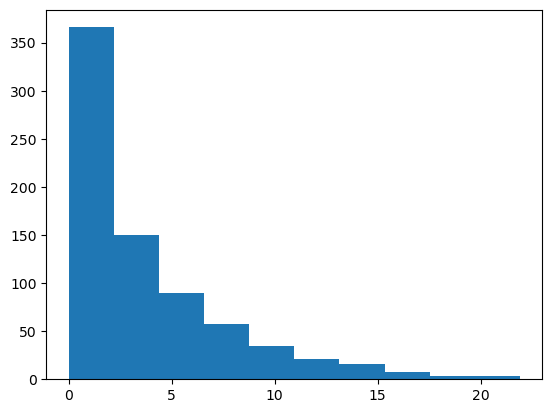

In [163]:
plt.hist(Y_train_value)

In [64]:
T = 200
gamma = 0.5
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 400
PREGRETS_random = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, 0.5,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards
    is_pos = (Y_train_value > threshold).astype(int)
    pos = is_pos.sum()
    neg = len(Y_train_value) - pos
    w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
    rf_value = train_model(X_train, Y_train_value, sample_weight=w)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t, t_prime_action, t_prime_value, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        ## PolicyIteration
        # X_train = np.vstack([X_train, next_features])
        # Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        ## Offline
        X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        Y_train_action = irewards[:T+delta_t]

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, 0.5,T = T+delta_t,normalization = False)
        is_pos = (Y_train_value > threshold).astype(int)
        pos = is_pos.sum()
        neg = len(Y_train_value) - pos
        w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value, sample_weight=w)
        
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS_random.append(PREGRET)


(200,)
(201, 57) (201,) (201,)
rep 0, T_train 201, pregret=0.6903
(202, 57) (202,) (202,)
rep 0, T_train 202, pregret=0.5714
(203, 57) (203,) (203,)
rep 0, T_train 203, pregret=0.9483
(204, 57) (204,) (204,)
rep 0, T_train 204, pregret=0.7091
(205, 57) (205,) (205,)
rep 0, T_train 205, pregret=0.7056
(206, 57) (206,) (206,)
rep 0, T_train 206, pregret=0.4750
(207, 57) (207,) (207,)
rep 0, T_train 207, pregret=0.4705
(208, 57) (208,) (208,)
rep 0, T_train 208, pregret=0.4716
(209, 57) (209,) (209,)
rep 0, T_train 209, pregret=0.2345
(210, 57) (210,) (210,)
rep 0, T_train 210, pregret=0.4925
(211, 57) (211,) (211,)
rep 0, T_train 211, pregret=0.3560
(212, 57) (212,) (212,)
rep 0, T_train 212, pregret=0.3440
(213, 57) (213,) (213,)
rep 0, T_train 213, pregret=0.4363
(214, 57) (214,) (214,)
rep 0, T_train 214, pregret=0.4340
(215, 57) (215,) (215,)
rep 0, T_train 215, pregret=0.6705
(216, 57) (216,) (216,)
rep 0, T_train 216, pregret=0.3352
(217, 57) (217,) (217,)
rep 0, T_train 217, pregr

[1.1732631222398733,
 0.9556851981975473,
 0.9600667260702085,
 0.9628758430414933,
 0.9634734274872437,
 0.9632991154290914,
 0.9584330776030703,
 0.9517631154705944,
 0.9508090132377341,
 0.9549314364601207,
 0.9591654391784351,
 0.9614226307705002,
 0.9604972846155317,
 0.95406011479972,
 0.9505564441713193,
 0.9435688144560038,
 0.8445069669316225,
 1.0341146683052072,
 0.7631860434045776,
 0.9006465822712377,
 0.9460130131518725,
 0.9612839166412297,
 0.9628660832914301,
 0.9683625830837557,
 0.9689601619718047,
 0.9660984531992483,
 1.0910896145662687,
 0.9920983256887311,
 0.9913799016050288,
 1.3902527060449439,
 1.4115436276971656,
 1.4339094204478502,
 1.4783777861304106,
 1.2463536579718977,
 1.002262857914627,
 1.2395912924925676,
 1.2347021282679125,
 1.2327065990388588,
 1.2317158913116193,
 1.2236348658820526,
 1.1945219420125621,
 1.0533734477087962,
 1.087863884248785,
 1.2252380799312657,
 1.2193975157053234,
 1.0720874865532195,
 0.9443063478373932,
 0.88906937943146

In [76]:
PREGRETS_random

[[0.6902737738844948,
  0.5713577159563991,
  0.948314150098154,
  0.7090540314500322,
  0.7055634996625111,
  0.4750297088062462,
  0.4705319906612388,
  0.4716329925177831,
  0.23445390183332138,
  0.4924623730782852,
  0.3559945957562667,
  0.34403066571439067,
  0.4363051970275052,
  0.43404963519299483,
  0.6704763443718201,
  0.33523801705470985,
  0.5293774079809666,
  0.5292468721055869,
  0.529181768631517,
  0.5291492578790337,
  0.529133012732482,
  0.7657671135930139,
  0.33471954938492643,
  0.6659424821514484,
  0.6624509343307006,
  0.4319166319985777,
  0.5637076095215616,
  0.5085048741067811,
  0.47509182374575515,
  0.4319160180576975,
  0.45281385419851117,
  0.4359979502385866,
  0.431914954197957,
  0.9524779090341536,
  1.0496741228831248,
  0.9599623535000396,
  0.9620014857678831,
  0.3350969780491539,
  0.33947747622118724,
  0.3975832020423741,
  0.39731442245894216,
  0.5459321529240512,
  0.5459045442797682,
  0.5458899168215601,
  0.5458809001297098,
  0.5

In [417]:
PREGRETS_arr = np.vstack(PREGRETS)
# PREGRETS_random_arr = np.vstack(PREGRETS_random)
np.savez(
    f"../results/OnlinePAFM/PVAFM_NN_oh_w_time0_lookahead{6}_10reps.npz",
    pregrets = PREGRETS_arr,
    # pregrets_offline = PREGRETS_random_arr
    )
    



[[0.66921283 0.80930889 0.3922477  ... 0.         0.         0.        ]
 [1.33086777 1.33064961 1.13970004 ... 0.         0.         0.        ]
 [1.18735611 1.33799328 1.18203661 ... 0.         0.         0.        ]
 ...
 [1.0583818  1.10518635 1.10479226 ... 0.         0.         0.        ]
 [1.21797087 1.06590272 1.05134186 ... 0.         0.         0.        ]
 [0.97880772 0.96571597 0.95861994 ... 0.         0.         0.        ]]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/1308894777.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PuRd')


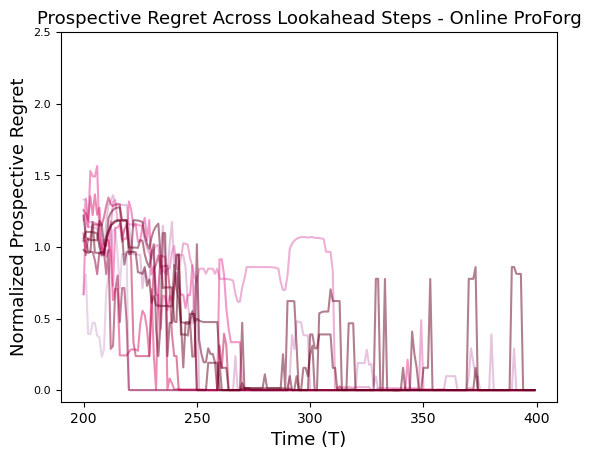

In [40]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_oh_w_time200_400_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_VA_arr = 0.5*data["pregrets_online"]
print(PREGRETS_VA_arr)

cmap = cm.get_cmap('PuRd')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(10):
    plt.plot(np.arange(200,400),PREGRETS_VA_arr[i],alpha = 0.5,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)
plt.show()



In [73]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]
print(PREGRETS_arr)



# fn = f"../results/OnlinePAFM/GBT_oh_w_time200_600_lookahead6_10reps.npz"
# data = np.load(fn)
# PREGRETS_arr = data["pregrets_online"]
# PREGRETS_random_arr = data["pregrets_offline"]
# print(PREGRETS_arr)

# cmap = cm.get_cmap('PuRd')
# fontsize = 13
# cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
# for i in range(5):
#     plt.plot(np.arange(200,600),PREGRETS_arr[i],alpha = 0.5,color = cmap_color[i])
# plt.xticks([200,250,300,350,400])
# plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
# plt.xlabel("Time (T)",fontsize = fontsize)
# plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# # plt.xscale('log')
# plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)
# plt.show()

[[ 0.69027377  0.71167193  0.812389   ...  0.          0.
   0.        ]
 [ 1.29586855  1.29532637  1.32910563 ...  0.19098756  0.1907499
   0.38114471]
 [ 1.17796892  1.18214189  1.16049757 ...  0.          0.
   0.        ]
 ...
 [ 1.05824382  1.10489755  1.10405666 ... -0.00609535 -0.00509898
   0.        ]
 [ 1.0586489   1.05144715  1.08201606 ...  0.          0.
   0.        ]
 [ 0.96872659  0.96152465  1.19291428 ...  0.          0.
   0.        ]]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/1856956894.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PuRd')


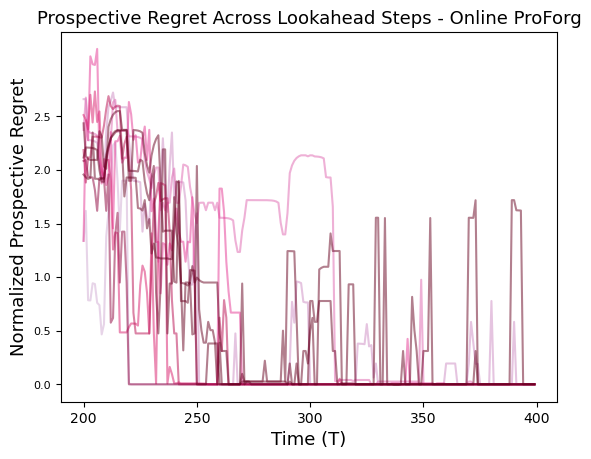

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/1856956894.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('OrRd')


Text(0.5, 1.0, 'Prospective Regret Across Lookahead Steps - Online ProForg')

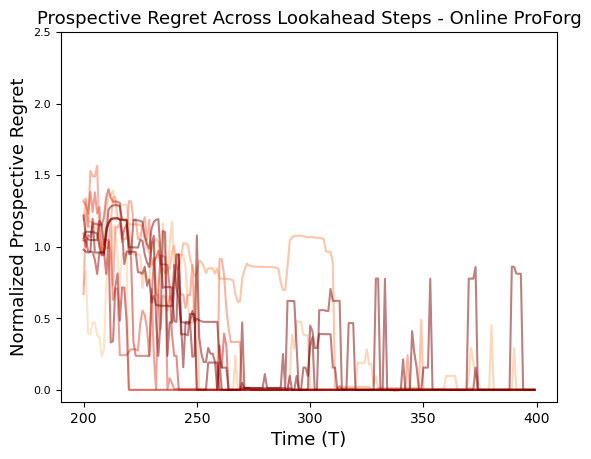

In [ ]:
cmap = cm.get_cmap('OrRd')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(10):
    plt.plot(np.arange(200,400),PREGRETS_arr[i],alpha = 0.5,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38913/3916517906.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


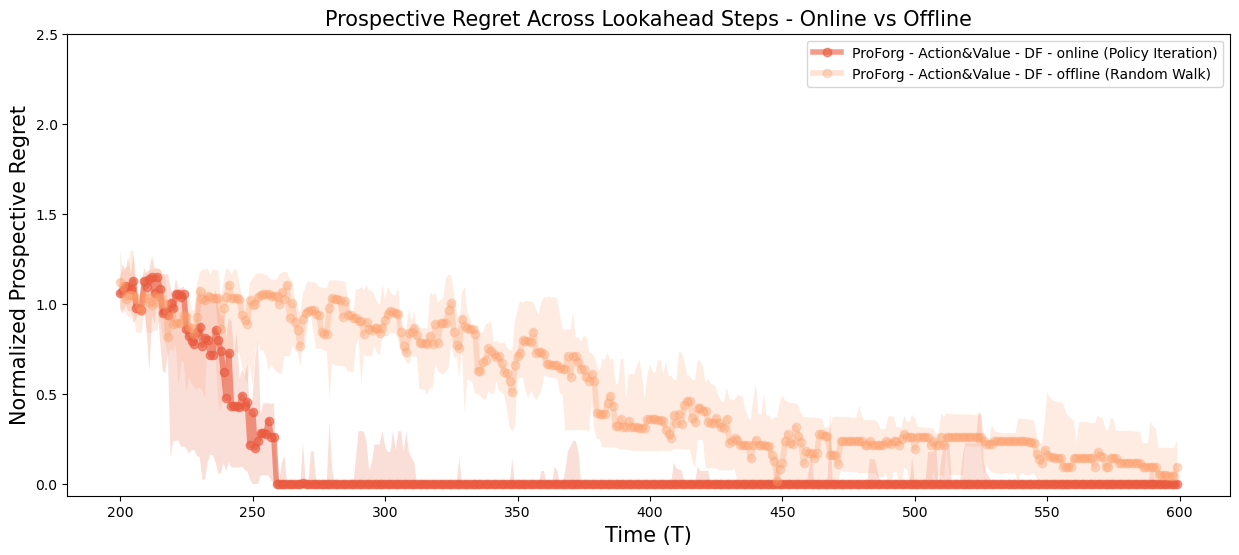

In [79]:

def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

plt.figure(figsize=(15, 6))

linewidth = 4
fontsize = 15
pafm_df_offline, pafm_df_online,pvafm_df_online= get_close_colors("OrRd", start = 0.45, delta = 0.2 , n = 3) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_RF_offline":pafm_df_offline,
          "PAFM_RF_online": pafm_df_online,
          "PVAFM_RF_online":pvafm_df_online,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql
          }

Ts_online = np.arange(200,600,1)
PREGRETS_arr = PREGRETS_arr
median = np.median(PREGRETS_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg - Action&Value - DF - online (Policy Iteration)')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_online"], alpha=0.20, edgecolor="none")


Ts_online = np.arange(200,600,1)
# median = np.median(PREGRETS_VA_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_VA_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_VA_arr, 75, axis=0)
# plt.plot(Ts_online, median,color=colors["PVAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg - Action&Value - DF - online')
# plt.fill_between(Ts_online, q25, q75, color=colors["PVAFM_RF_online"], alpha=0.20, edgecolor="none")


PREGRETS_random_arr = PREGRETS_random_arr
median = np.median(PREGRETS_random_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - Action&Value - DF - offline (Random Walk)')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_offline"], alpha=0.20, edgecolor="none")


# median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
# plt.plot(Ts_DF, median,color=colors["PAFM_RF"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - offline')
# plt.fill_between(Ts_DF, q25, q75, color=colors["PAFM_RF"], alpha=0.20, edgecolor="none")


# xticks = Ts_online + Ts_DF
# xticklabels = [str(v) if v in [128,256,512] else "" 
#                for i, v in enumerate(xticks)]

# plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.xticks([200,250,300,350,400,450,500,550,600])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
plt.title('Prospective Regret Across Lookahead Steps - Online vs Offline',fontsize = fontsize)
plt.legend()